In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
data = pd.read_csv(r"C:\Users\reva\Downloads\train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
print("Dataset Info:\n", data.info())
print("\nSummary Statistics:\n", data.describe())
print("\nMissing Values:\n", data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Dataset Info:
 None

Summary Statistics:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.52

In [31]:
# DATA PREPROCESSING 

# Verify column names
print("Original columns:\n", data.columns.tolist())

# Remove leading/trailing spaces from column names
data.columns = data.columns.str.strip()
print("\nCleaned columns:\n", data.columns.tolist())

#Verify columns exist before proceeding
required_columns = ['Age', 'Embarked', 'Cabin', 'Ticket', 'Sex', 'Fare']
for col in required_columns:
    if col not in data.columns:
        print(f"Warning: Column '{col}' not found!")

# Handling Missing Values
# Age: median imputation
if 'Age' in data.columns:
    data['Age'] = data['Age'].fillna(data['Age'].median())

# Embarked: mode imputation
if 'Embarked' in data.columns:
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Drop irrelevant columns
drop_cols = [col for col in ['Cabin', 'Ticket'] if col in data.columns]
data = data.drop(drop_cols, axis=1)

# Outlier Detection & Removal (Fare)
if 'Fare' in data.columns:
    Q1 = data['Fare'].quantile(0.25)
    Q3 = data['Fare'].quantile(0.75)
    IQR = Q3 - Q1
    data = data[~((data['Fare'] < (Q1 - 1.5 * IQR)) | (data['Fare'] > (Q3 + 1.5 * IQR)))]

# Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder

# Sex → Label Encoding
if 'Sex' in data.columns:
    le = LabelEncoder()
    data['Sex'] = le.fit_transform(data['Sex'])  # female=0, male=1

# Embarked → One-Hot Encoding
if 'Embarked' in data.columns:
    data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

# Verification
print("\nMissing values after preprocessing:\n", data.isnull().sum())
print("\nData types:\n", data.dtypes)
print("\nData shape:", data.shape)
print("\nFirst 5 rows:\n", data.head())


Original columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Cleaned columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Missing values after preprocessing:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q        bool
Embarked_S        bool
dtype: object

Data shape: (750, 11)

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3

Summary Statistics:

       PassengerId    Survived      Pclass         Sex         Age  \
count   750.000000  750.000000  750.000000  750.000000  750.000000   
mean    445.746667    0.325333    2.508000    0.688000   28.555000   
std     260.420103    0.468812    0.711766    0.463619   12.744883   
min       1.000000    0.000000    1.000000    0.000000    0.420000   
25%     214.250000    0.000000    2.000000    0.000000   22.000000   
50%     449.500000    0.000000    3.000000    1.000000   28.000000   
75%     670.750000    1.000000    3.000000    1.000000   34.000000   
max     891.000000    1.000000    3.000000    1.000000   80.000000   

            SibSp       Parch        Fare  
count  750.000000  750.000000  750.000000  
mean     0.438667    0.337333   16.477733  
std      0.910317    0.790172   11.581224  
min      0.000000    0.000000    0.000000  
25%      0.000000    0.000000    7.895800  
50%      0.000000    0.000000   12.281250  
75%      1.000000    0.000000   25.84062

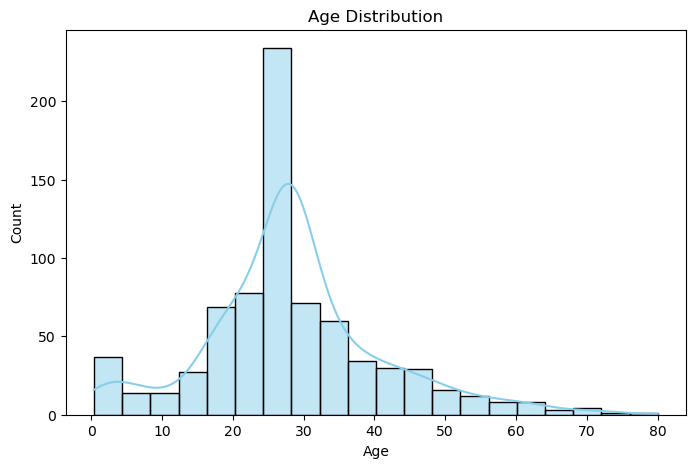

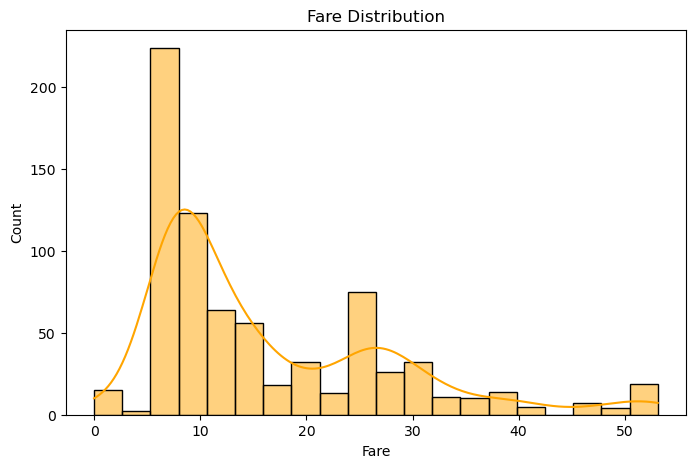

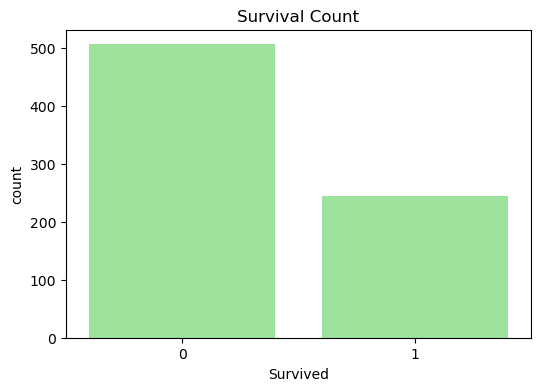

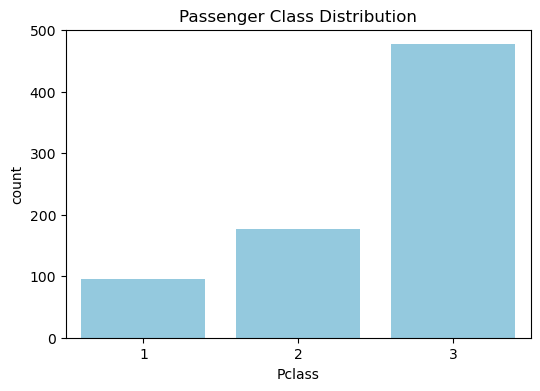

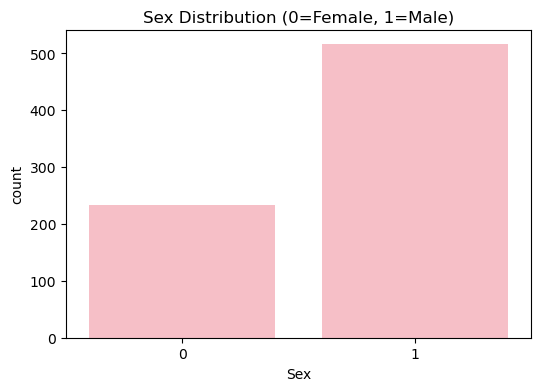

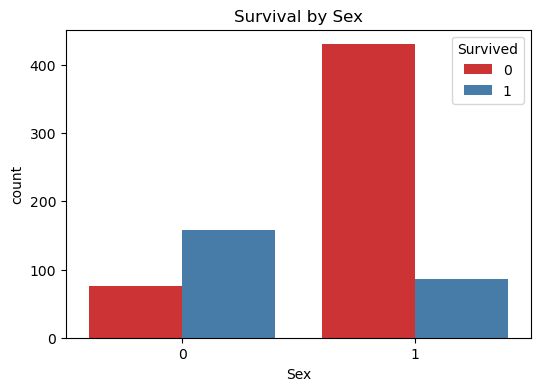

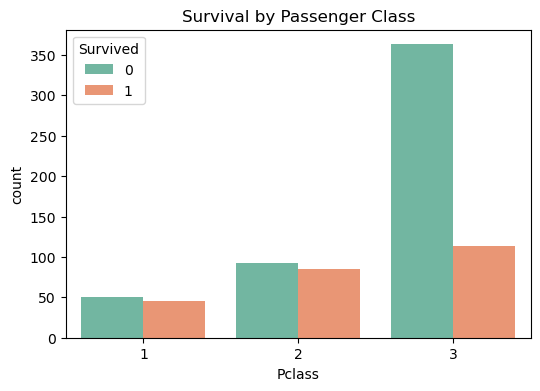

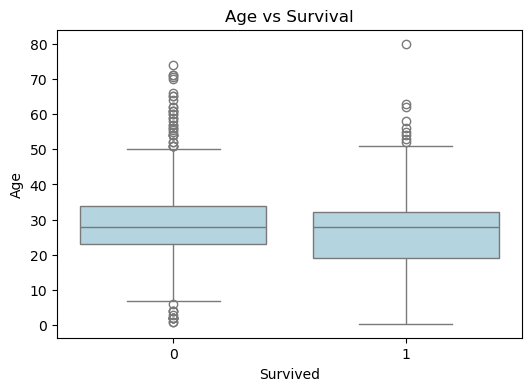

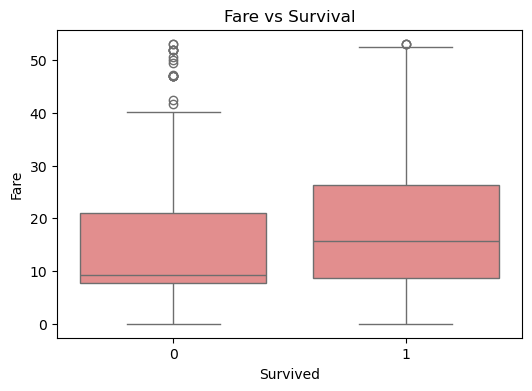

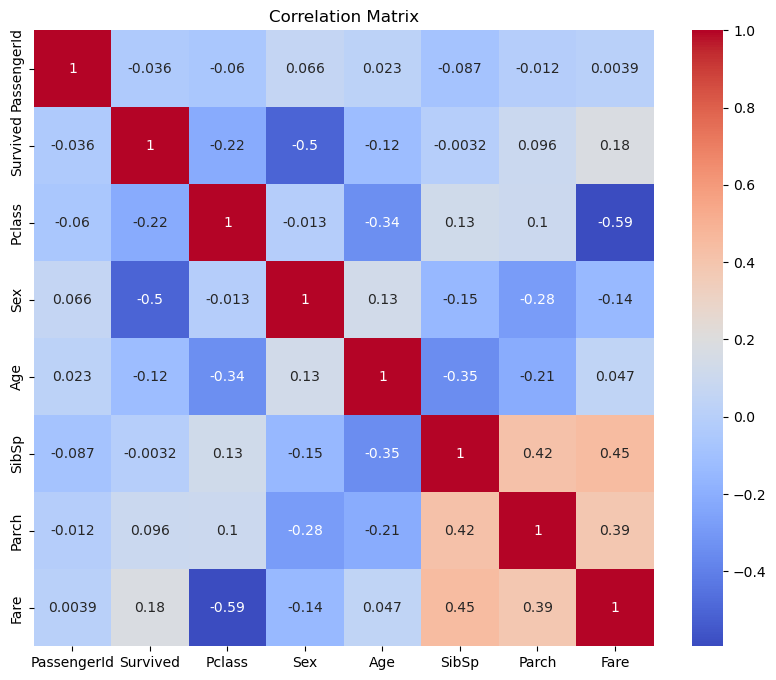

In [33]:
# 5. EXPLORATORY DATA ANALYSIS (EDA) 

import matplotlib.pyplot as plt
import seaborn as sns

# Summary Statistics
print("Summary Statistics:\n")
print(data.describe())

# Univariate Analysis

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Fare distribution
plt.figure(figsize=(8,5))
sns.histplot(data['Fare'], bins=20, kde=True, color='orange')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

# Count of Survived vs Not Survived
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=data, color='lightgreen')
plt.title('Survival Count')
plt.show()

# Count of Pclass
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=data, color='skyblue')
plt.title('Passenger Class Distribution')
plt.show()

# Sex distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=data, color='lightpink')
plt.title('Sex Distribution (0=Female, 1=Male)')
plt.show()

# Bivariate Analysis

# Survival vs Sex
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=data, palette='Set1')
plt.title('Survival by Sex')
plt.show()

# Survival vs Pclass
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=data, palette='Set2')
plt.title('Survival by Passenger Class')
plt.show()

# Boxplot: Age vs Survived
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=data, color='lightblue')
plt.title('Age vs Survival')
plt.show()

# Boxplot: Fare vs Survived
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Fare', data=data, color='lightcoral')
plt.title('Fare vs Survival')
plt.show()

# Correlation Heatmap (numeric columns only)
numeric_data = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [35]:
# 6. Hypothesis Testing

# Hypothesis 1: Gender vs Survival (Chi-Square Test)
contingency = pd.crosstab(data['Sex'], data['Survived'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("Chi-Square Test: Gender vs Survival")
print("Chi2:", chi2, "p-value:", p)
if p < 0.05:
    print("→ Reject null hypothesis: Gender affects survival")
else:
    print("→ Fail to reject null: No significant effect")

# Hypothesis 2: Pclass vs Survival (Chi-Square Test)
contingency2 = pd.crosstab(data['Pclass'], data['Survived'])
chi2_2, p2, dof2, expected2 = stats.chi2_contingency(contingency2)
print("\nChi-Square Test: Pclass vs Survival")
print("Chi2:", chi2_2, "p-value:", p2)
if p2 < 0.05:
    print("→ Reject null hypothesis: Passenger class affects survival")
else:
    print("→ Fail to reject null: No significant effect")

Chi-Square Test: Gender vs Survival
Chi2: 187.3819994728498 p-value: 1.1852347587286942e-42
→ Reject null hypothesis: Gender affects survival

Chi-Square Test: Pclass vs Survival
Chi2: 44.54343904181762 p-value: 2.1257643015581653e-10
→ Reject null hypothesis: Passenger class affects survival


In [37]:
# Modeling (Logistic Regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

# Evaluate Logistic Regression
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.7548387096774194
Confusion Matrix:
 [[82 13]
 [25 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81        95
           1       0.73      0.58      0.65        60

    accuracy                           0.75       155
   macro avg       0.75      0.72      0.73       155
weighted avg       0.75      0.75      0.75       155

